# Predicting Soccer Match Outcomes Using Machine Learning

###Xavier Bailey
###AAI201: Machine Learning

This notebook builds, trains, and evaluates machine learning models that predict soccer match outcomes (Home Win / Draw / Away Win) using historical match data and pre-match team statistics.


## 1. Problem Statement

Soccer match prediction is generally driven by human intuition. Things like analysts, coaches, and fans form opinions based on experience, which can be biased or inconsistent. This matters because match predictions are used by sports analysts, broadcasters, coaching staff, and fans, and better predictions mean more objective, data-driven insight into what actually drives results.

This project treats match outcome prediction as a 3-class classification problem: `Home Win`, `Draw`, or `Away Win`, using machine learning to identify patterns that predict results better than intuition alone, while  avoiding data leakage.


In [1]:
!pip install -q xgboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
np.random.seed(42)


## 2. Data Source

**Dataset:** International Football Results, 1872–present
**Source:** Public GitHub CSV (mirrors the "International Football Results" dataset also available on Kaggle) — no login/API key required, which makes this notebook fully self-contained and reproducible.
**URL:** https://raw.githubusercontent.com/martj42/international_results/master/results.csv

**Columns:** `date`, `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `city`, `country`, `neutral`

Will filter to matches from 2000 onward to keep the data recent and manageable (~25,000+ matches), matching the scale proposed.

In [2]:
url = "https://raw.githubusercontent.com/martj42/international_results/master/results.csv"
df = pd.read_csv(url)
print("Shape:", df.shape)
df.head()


Shape: (49520, 9)


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


In [3]:
df.info()
print("\nMissing values:\n", df.isnull().sum())
print("\nDate range:", df['date'].min(), "to", df['date'].max())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49520 entries, 0 to 49519
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   date        49520 non-null  object
 1   home_team   49520 non-null  object
 2   away_team   49520 non-null  object
 3   home_score  49520 non-null  int64 
 4   away_score  49520 non-null  int64 
 5   tournament  49520 non-null  object
 6   city        49520 non-null  object
 7   country     49520 non-null  object
 8   neutral     49520 non-null  bool  
dtypes: bool(1), int64(2), object(6)
memory usage: 3.1+ MB

Missing values:
 date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Date range: 1872-11-30 to 2026-07-19


## 3. Preprocessing Steps

1. Parse dates and drop any rows missing team names or scores.
2. Filter to matches from **2000-01-01 onward**.
3. Sort chronologically (required for building "pre-match" rolling features later, so no future data leaks backward).
4. Create the classification target (`outcome`) from each match's final score.


In [4]:
df['date'] = pd.to_datetime(df['date'])
df = df.dropna(subset=['home_team', 'away_team', 'home_score', 'away_score']).copy()
df = df[df['date'] >= '2000-01-01'].copy()
df = df.sort_values('date').reset_index(drop=True)

print(f"Matches after filtering (2000+): {len(df)}")


Matches after filtering (2000+): 25458


In [5]:
def get_outcome(row):
    if row['home_score'] > row['away_score']:
        return 'Home Win'
    elif row['home_score'] < row['away_score']:
        return 'Away Win'
    else:
        return 'Draw'

df['outcome'] = df.apply(get_outcome, axis=1)

print(df['outcome'].value_counts())
print(df['outcome'].value_counts(normalize=True).round(3))


outcome
Home Win    12255
Away Win     7275
Draw         5928
Name: count, dtype: int64
outcome
Home Win    0.481
Away Win    0.286
Draw        0.233
Name: proportion, dtype: float64


## 4. Feature Engineering

**Important design choice** — avoiding data leakage: the raw `home_score`/`away_score` of a match *define* the outcome, so we cannot use them (or anything derived directly from them, like that match's goal difference) as predictive features — that would be cheating. Instead we engineer features using each team's history from before the match date only:

- `home_form` / `away_form` — average points earned (3/1/0) over each team's last 5 matches prior to this match
- `home_avg_goals_for` / `away_avg_goals_for` — average goals scored over the last 5 matches
- `home_avg_goals_against` / `away_avg_goals_against` — average goals conceded over the last 5 matches
- `home_advantage` — 1 if the match was played at the home team's venue (not neutral), else 0

To do this we reshape the data into a "team history" table (one row per team per match) so we can compute rolling averages per team, then merge those pre-match stats back onto each match.


In [6]:
# Build a long-format table, one row per team per match
home_hist = df[['date', 'home_team', 'away_team', 'home_score', 'away_score', 'neutral']].copy()
home_hist.columns = ['date', 'team', 'opponent', 'goals_for', 'goals_against', 'neutral']
home_hist['is_home'] = 1

away_hist = df[['date', 'away_team', 'home_team', 'away_score', 'home_score', 'neutral']].copy()
away_hist.columns = ['date', 'team', 'opponent', 'goals_for', 'goals_against', 'neutral']
away_hist['is_home'] = 0

team_history = pd.concat([home_hist, away_hist], ignore_index=True)
team_history['points'] = np.where(team_history['goals_for'] > team_history['goals_against'], 3,
                            np.where(team_history['goals_for'] == team_history['goals_against'], 1, 0))
team_history = team_history.sort_values(['team', 'date']).reset_index(drop=True)

team_history.head()


,date,team,opponent,goals_for,goals_against,neutral,is_home,points
0,2012-09-25,Abkhazia,Artsakh,1,1,False,1,1
1,2012-10-21,Abkhazia,Artsakh,0,3,False,0,0
2,2013-09-23,Abkhazia,South Ossetia,3,0,False,1,3
3,2014-06-01,Abkhazia,Occitania,1,1,True,1,1
4,2014-06-02,Abkhazia,Sápmi,2,1,False,0,3


In [7]:
WINDOW = 5  # "recent form" = last 5 matches

# shift(1) BEFORE rolling ensures we only ever look at matches strictly before the current one
team_history['form_points'] = (team_history.groupby('team')['points']
                                .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=WINDOW).mean()))
team_history['avg_goals_for'] = (team_history.groupby('team')['goals_for']
                                  .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=WINDOW).mean()))
team_history['avg_goals_against'] = (team_history.groupby('team')['goals_against']
                                      .transform(lambda x: x.shift(1).rolling(WINDOW, min_periods=WINDOW).mean()))

team_history[['team', 'date', 'form_points', 'avg_goals_for', 'avg_goals_against']].dropna().head()


,team,date,form_points,avg_goals_for,avg_goals_against
5,Abkhazia,2014-06-04,1.6,1.4,1.2
6,Abkhazia,2014-06-05,1.6,1.2,1.0
7,Abkhazia,2014-06-07,1.8,1.8,1.0
8,Abkhazia,2015-05-05,1.2,1.2,1.2
9,Abkhazia,2015-05-14,1.6,1.2,1.0


In [8]:
# Split rolling stats back into home-side and away-side tables, then merge onto the original matches
home_feat = team_history[team_history['is_home'] == 1][
    ['date', 'team', 'opponent', 'form_points', 'avg_goals_for', 'avg_goals_against']]
home_feat.columns = ['date', 'home_team', 'away_team', 'home_form', 'home_avg_goals_for', 'home_avg_goals_against']

away_feat = team_history[team_history['is_home'] == 0][
    ['date', 'team', 'opponent', 'form_points', 'avg_goals_for', 'avg_goals_against']]
away_feat.columns = ['date', 'away_team', 'home_team', 'away_form', 'away_avg_goals_for', 'away_avg_goals_against']

df = df.merge(home_feat, on=['date', 'home_team', 'away_team'], how='left')
df = df.merge(away_feat, on=['date', 'home_team', 'away_team'], how='left')

df.head()


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,outcome,home_form,home_avg_goals_for,home_avg_goals_against,away_form,away_avg_goals_for,away_avg_goals_against
0,2000-01-04,Egypt,Togo,2,1,Friendly,Aswan,Egypt,False,Home Win,NaN,NaN,NaN,NaN,NaN,NaN
1,2000-01-07,Tunisia,Togo,7,0,Friendly,Tunis,Tunisia,False,Home Win,NaN,NaN,NaN,NaN,NaN,NaN
2,2000-01-08,Trinidad and Tobago,Canada,0,0,Friendly,Port of Spain,Trinidad and Tobago,False,Draw,NaN,NaN,NaN,NaN,NaN,NaN
3,2000-01-09,Burkina Faso,Gabon,1,1,Friendly,Ouagadougou,Burkina Faso,False,Draw,NaN,NaN,NaN,NaN,NaN,NaN
4,2000-01-09,Guatemala,Armenia,1,1,Friendly,Los Angeles,United States,True,Draw,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df['home_advantage'] = (~df['neutral']).astype(int)

feature_cols = ['home_form', 'home_avg_goals_for', 'home_avg_goals_against',
                'away_form', 'away_avg_goals_for', 'away_avg_goals_against', 'home_advantage']
target_col = 'outcome'

df_model = df.dropna(subset=feature_cols).copy()

print(f"Rows before requiring {WINDOW}+ prior matches per team: {len(df)}")
print(f"Rows after (usable for modeling): {len(df_model)}")


Rows before requiring 5+ prior matches per team: 25458
Rows after (usable for modeling): 24381


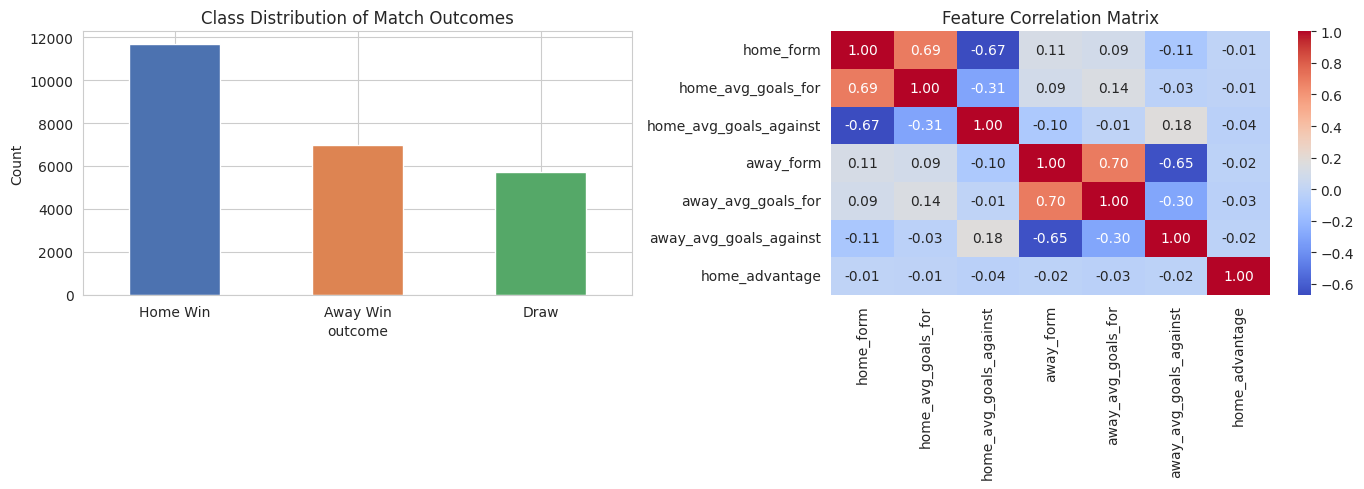

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df_model['outcome'].value_counts().plot(kind='bar', ax=axes[0],
                                         color=['#4C72B0', '#DD8452', '#55A868'])
axes[0].set_title('Class Distribution of Match Outcomes')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

corr = df_model[feature_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1])
axes[1].set_title('Feature Correlation Matrix')

plt.tight_layout()
plt.show()


## 5. Class Imbalance (Bias & Fairness — Part 1)

As expected, `Draw` is the minority class — draws are less common than decisive results. If left unaddressed, models tend to just never predict draws, since ignoring the minority class still yields high raw accuracy. We address this with:

- `class_weight='balanced'` in Logistic Regression and Random Forest, which automatically re-weights the loss function so minority-class errors count more
- Inverse-frequency sample weights for XGBoost (it doesn't have a native multi-class `class_weight` option)
- We report macro-averaged precision/recall/F1 (not just accuracy) throughout, since macro-averaging treats all 3 classes equally and won't hide poor draw performance the way plain accuracy can


In [11]:
le = LabelEncoder()
df_model['outcome_encoded'] = le.fit_transform(df_model['outcome'])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

X = df_model[feature_cols]
y = df_model['outcome_encoded']

# 70 / 15 / 15 train / validation / test split, stratified to preserve class balance in each split
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f"Train: {X_train.shape} | Val: {X_val.shape} | Test: {X_test.shape}")


Label mapping: {'Away Win': np.int64(0), 'Draw': np.int64(1), 'Home Win': np.int64(2)}
Train: (17066, 7) | Val: (3657, 7) | Test: (3658, 7)


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


## 6. Model 1 — Logistic Regression

Logistic Regression is our interpretable baseline. **Overfitting prevention:** L2 regularization (`penalty='l2'`) shrinks coefficients toward zero, and we validate with 5-fold stratified cross-validation rather than trusting a single train/test split.

In [13]:
log_reg = LogisticRegression(penalty='l2', C=1.0, class_weight='balanced',
                              max_iter=1000, random_state=42)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
print(f"Logistic Regression CV F1-macro: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

log_reg.fit(X_train_scaled, y_train)
val_preds_lr = log_reg.predict(X_val_scaled)
print("Validation Accuracy:", round(accuracy_score(y_val, val_preds_lr), 4))


Logistic Regression CV F1-macro: 0.4438 (+/- 0.0026)
Validation Accuracy: 0.4848


## 7. Model 2 — Random Forest

Random Forest can capture non-linear relationships between form/scoring stats and outcomes. **Overfitting prevention:** we cap `max_depth` and set a minimum `min_samples_leaf`, which stops individual trees from memorizing the training data.

In [14]:
rf = RandomForestClassifier(n_estimators=200, max_depth=8, min_samples_leaf=20,
                             class_weight='balanced', random_state=42, n_jobs=-1)

cv_scores_rf = cross_val_score(rf, X_train_scaled, y_train, cv=cv, scoring='f1_macro')
print(f"Random Forest CV F1-macro: {cv_scores_rf.mean():.4f} (+/- {cv_scores_rf.std():.4f})")

rf.fit(X_train_scaled, y_train)
val_preds_rf = rf.predict(X_val_scaled)
print("Validation Accuracy:", round(accuracy_score(y_val, val_preds_rf), 4))


Random Forest CV F1-macro: 0.4410 (+/- 0.0069)
Validation Accuracy: 0.4714


## 8. Model 3 — XGBoost

XGBoost usually gets the best performance on structured/tabular data like this. **Overfitting prevention:** shallow trees (`max_depth=4`), row/column subsampling, and **early stopping** — training halts once validation loss stops improving, so the model doesn't keep fitting noise.

In [15]:
class_counts = y_train.value_counts()
weight_map = (class_counts.max() / class_counts).to_dict()
sample_weights = y_train.map(weight_map)

xgb_model = xgb.XGBClassifier(
    n_estimators=300, max_depth=4, learning_rate=0.05,
    subsample=0.8, colsample_bytree=0.8,
    objective='multi:softprob', num_class=3,
    eval_metric='mlogloss', early_stopping_rounds=20,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train, sample_weight=sample_weights,
              eval_set=[(X_val_scaled, y_val)], verbose=False)

val_preds_xgb = xgb_model.predict(X_val_scaled)
print("Validation Accuracy:", round(accuracy_score(y_val, val_preds_xgb), 4))
print(f"Best boosting round (early stopping kicked in at): {xgb_model.best_iteration}")


Validation Accuracy: 0.4785
Best boosting round (early stopping kicked in at): 116


## 9. Model 4 — Multi-Layer Perceptron (MLP)

A small neural network for comparison. **Overfitting prevention:** L2 weight regularization (`alpha`) plus built-in early stopping on a held-out validation slice of the training data.

In [16]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', alpha=0.01,
                     early_stopping=True, validation_fraction=0.15, n_iter_no_change=10,
                     max_iter=500, random_state=42)

mlp.fit(X_train_scaled, y_train)
val_preds_mlp = mlp.predict(X_val_scaled)
print("Validation Accuracy:", round(accuracy_score(y_val, val_preds_mlp), 4))


Validation Accuracy: 0.533


## 10. Model Comparison

Now that all models are trained (validation set was only used for tuning/early stopping), we do a single, final evaluation on the untouched test set for a fair comparison.

In [17]:
models = {
    'Logistic Regression': log_reg,
    'Random Forest': rf,
    'XGBoost': xgb_model,
    'MLP': mlp
}

results = []
for name, model in models.items():
    preds = model.predict(X_test_scaled)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, preds),
        'Precision (macro)': precision_score(y_test, preds, average='macro'),
        'Recall (macro)': recall_score(y_test, preds, average='macro'),
        'F1 (macro)': f1_score(y_test, preds, average='macro')
    })

results_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
results_df


,Model,Accuracy,Precision (macro),Recall (macro),F1 (macro)
0,Logistic Regression,0.480044,0.450396,0.454029,0.450380
1,Random Forest,0.471843,0.454041,0.452495,0.449829
2,XGBoost,0.471022,0.448335,0.447992,0.445624
3,MLP,0.530891,0.429881,0.421475,0.369603


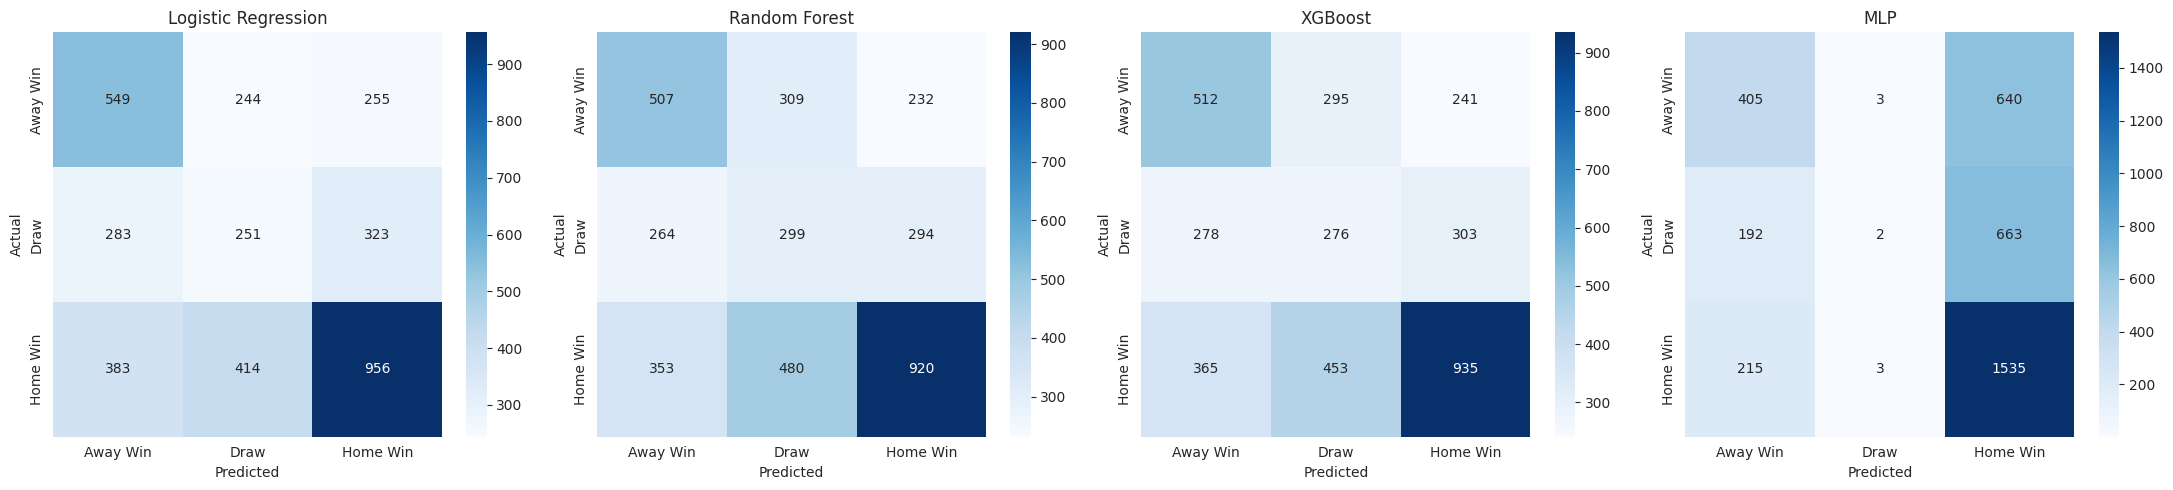

Detailed classification report for best model (Logistic Regression):

              precision    recall  f1-score   support

    Away Win       0.45      0.52      0.49      1048
        Draw       0.28      0.29      0.28       857
    Home Win       0.62      0.55      0.58      1753

    accuracy                           0.48      3658
   macro avg       0.45      0.45      0.45      3658
weighted avg       0.49      0.48      0.48      3658



In [18]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for ax, (name, model) in zip(axes, models.items()):
    preds = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_)
    ax.set_title(name)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.tight_layout()
plt.show()

best_model_name = results_df.iloc[0]['Model']
print(f"Detailed classification report for best model ({best_model_name}):\n")
print(classification_report(y_test, models[best_model_name].predict(X_test_scaled), target_names=le.classes_))


## 11. Feature Importance

Which pre-match stats actually drive the prediction?

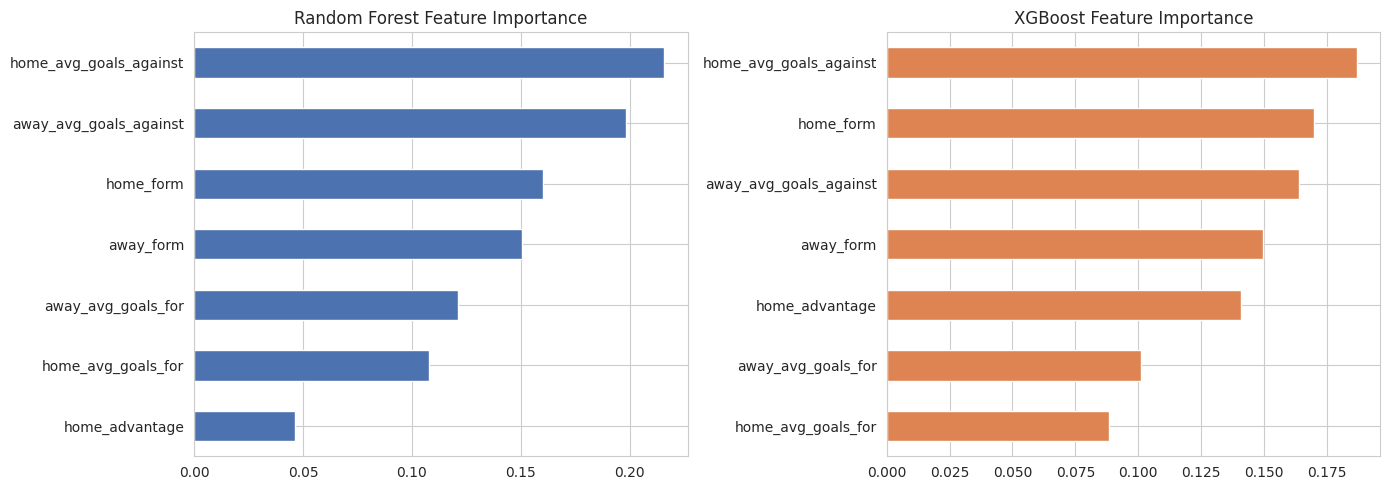

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

rf_importance = pd.Series(rf.feature_importances_, index=feature_cols).sort_values()
rf_importance.plot(kind='barh', ax=axes[0], color='#4C72B0')
axes[0].set_title('Random Forest Feature Importance')

xgb_importance = pd.Series(xgb_model.feature_importances_, index=feature_cols).sort_values()
xgb_importance.plot(kind='barh', ax=axes[1], color='#DD8452')
axes[1].set_title('XGBoost Feature Importance')

plt.tight_layout()
plt.show()


## 12. Bias & Fairness

- **Historical data bias:** Larger footballing nations (e.g., long-established European/South American teams) have far more matches in the dataset than smaller federations, so the model has seen much more history for those teams. This can make predictions for certain teams less reliable, even though we deliberately avoided one-hot-encoding team identity (which would have let the model directly memorize "this team always wins") in favor of *form-based* features that generalize better across teams.
- **Fairness across teams:** Because features are relative (recent form, goals for/against) rather than raw team identity, the model should treat a strong newcomer similarly to a strong historic team, but confidence should be lower for teams with little match history.
- **Tournament-type bias:** Friendlies, qualifiers, and major tournaments (World Cup, etc.) can have very different competitive intensity, which this dataset lumps together via the `tournament` column — a possible extension is to weight or filter by tournament importance.


## 13. Overfitting Prevention — Summary

| Technique | Where used |
|---|---|
| Train / validation / test split (70/15/15) | All models |
| Stratified 5-fold cross-validation | Logistic Regression, Random Forest |
| L2 regularization | Logistic Regression, MLP (`alpha`) |
| Limited tree depth / min leaf size | Random Forest, XGBoost |
| Early stopping | XGBoost, MLP |
| Class-balanced weighting | All models (addresses imbalance, not overfitting directly, but prevents the model from trivially "overfitting" to the majority class) |


## 14. Reflection

**Key decisions**: I went with form-based features (recent points, avg goals for/against) instead of just encoding team names. The tradeoff was real, I had to drop about 1,000+ early matches per team since there wasn't 5 games of history yet to build a "form" number from. Felt a little wasteful losing that data, but using team names directly felt like cheating (the model would just memorize "Brazil = good" instead of actually learning anything).

**Challenges**: Honestly, the rolling-window feature engineering was the hardest part — making sure I was shifting by 1 match before rolling so I wasn't accidentally letting a match "see" itself. It took a couple of tries to get right. Class imbalance was the other issue — draws are just rare (~23% of matches) and every model wanted to ignore them.

**What I learned / what surprised me**: I expected XGBoost to run away with it since it's the "fancy" model, but it didn't. Logistic Regression and Random Forest both landed around 0.45 F1-macro, basically tied, and XGBoost was actually right behind at 0.446. The bigger surprise was the MLP: it had the best accuracy (53%) but the worst F1-macro (0.37) of all four models. That's a pretty good example of why accuracy alone is a misleading metric, it was almost certainly just leaning hard into predicting "Home Win" a lot, since that's the majority class, and getting away with it accuracy-wise while quietly bombing on Draws and Away Wins.

**Next steps**: If I had more time I'd want head-to-head history between the two specific teams, maybe try SMOTE on the training set, and actually tune hyperparameters instead of using reasonable defaults